# LEAF & CROP
## Latent encoding of agricultural features and context-based recommendations for optimised planting
#### Piotr Szewczyk, Theo Hanig, Tim Hager

### Motivation
Traditional agricultural oftentimes relies on an invasive modification approach: to maximize crop yields, farmers artificially adjust soil chemistry through the heavy application of synthetic fertilizers and chemical treatments to force compatibility with a desired crop. From an ecological and economic perspective, this practice is highly unsustainable. It accelerates long-term ecosystem degradation, compromises soil biology, and imposes financial burdens due to rising chemical costs.<br>
With LEAF & CROP we want to propose a data-driven approach aligned with the principles of sustainable Precision Agriculture. Instead of altering the ecosystem to fit a specific crop, we want to utilize machine learning to select and recommend optimal crops based on existing soil and weather conditions.

### Crop recommendation dataset
From Kaggle: https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset/data<br>
We use the Crop Recommendation Dataset which contains environmental readings captured via IoT devices across India. Th dataset consist of a 7-dimensional feature vector (comprising Nitrogen, Phosphorus, Potassium, Soil pH, Temperature, Humidity, and Rainfall) and a label referencing one out of 22 differet crops planted with these soil and weather conditions. the target crop represents the agro-ecological optimum. It is the specific crop that delivered the highest agricultural yield and survival rate under the combination of the soil and meteorological features.

### Approach
We implemented a hybrid deeplearning network based on representation learning through a multi-task Autoencoder framework. The network compresses the 7-dimensional input feature space into a 5-dimensional latent representation. This latent space serves as an abstract representation, a "digital fingerprint", capturing the dependencies of the environmental variables.<br>
On top of this latent space, a classification head is trained to predict the most suitable crop out of the 22 classes. To ensure a robust latent space suitable for this classification, the framework uses Joint Training to simultaneously train a balanced multi-task loss (Mean Squared Error for reconstruction and Cross-Entropy for classification). The encoder and decoder layers are frozen at an optimized milestone of the training, allowing the classification head to "fine-tune" on a secured latent space.

### Ressources
We used different findings from papers to build an optimal pipeline, although we did not find a similar approach in the literature.<br><br>
**Enhancing the Crop Recommendation Systems Using Machine Learning Approaches**<br>
Hossny, Eman, Abd El-Rahman A. Awad, and Fatma A. Omara<br>
World Conference on Internet of Things: Applications & Future. Singapore: Springer Nature Singapore, 2024<br>
This paper provides a proven range for the Gaussian Noise augmentation of the data.
<br><br>
**Incorporating soil information with machine learning for crop recommendation to improve agricultural output**<br>
Afzal, Hadeeqa, et al<br>
Scientific Reports 15.1 (2025): 8560<br>
This paper contains different useful approaches for the Explainatory Data Analysis, which we implemented as well.
<br><br>
**SMOTE-Enhanced Machine Learning Models for Reliable Crop Recommendation System**<br>
Ayrancı, Ahmet Aytuğ, Mert Hayar, and Atilla Özmen<br>
2025 9th International Symposium on Multidisciplinary Studies and Innovative Technologies (ISMSIT). IEEE, 2025<br>
This paper discusses the benefit of using SMOTE (Synthetic Minority Oversampling Technique) to generate new samples for the already balanced dataset by interpolation. We use this approach to provide an increased training set.

### Hardware
We used Google Colab with the T4 GPU ressources for training our model as well as a MacBook Air with Apple M2 chip and 8GB RAM. On the MAcBook we achieved our top result.<br>
Our pipeline runs ob Google Colab as a "plug & play" solution, when the whole folder is uploaded to Google Drive and the Notebook is opened, the training should run without any additional steps.

### Short summary of results
...

## Imports and configurations

### Imports of useful libraries

#### Pip installs

In [321]:
!pip install -q python-box
!pip install -q scikit-learn
!pip install -q ax-platform
!pip install -q torch
!pip install -q torchvision
!pip install -q torchmetrics
!pip install -q wandb
!pip install -q PyYAML
!pip install -q pandas
!pip install -q numpy
!pip install -q imbalanced-learn
!pip install -q seaborn
!pip install -q matplotlib
!pip install -q umap-learn


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip insta

#### Imports

In [322]:
# Libraries for logging and general utilities
import random
import logging
import wandb
import time
import math
import yaml
from box.box import Box
import functools
import operator
import gc

# Libraries for data manipulation and analysis
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from ax.service.ax_client import AxClient, ObjectiveProperties
from imblearn.over_sampling import SMOTE

# Libraries for visualization
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

# Helpful libraries
from datetime import datetime
from pathlib import Path
from typing import Any, Tuple, Union
import os

# Deep learning libraries
import torch
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchmetrics.classification import (MulticlassAccuracy, MulticlassConfusionMatrix,
                                         MulticlassF1Score, MulticlassAUROC)
from torchmetrics.regression import MeanSquaredError, MeanAbsoluteError

### Configuration to control model architecture and training

We created a configuration based on YAML for a more flexible and maintainable pipeline. The configuration consists of a main part with the parameters for general functionalities like the random seed to ensure deterministic and reproducable outcomes, the differenciation between local running and running on Colab as well as the file paths to the ressources and parameters for the logging process to W&B. Also the dataset and data augmentation parameters are placed in this configuration.<br><br>
In the model specific configuration file(s), the parameters defining the architecture of the model are placed as well as the model specific training parameters such as learning rate and number of epochs.<br><br>
The last configuration is used to activate and control the hyperparameter optimization using the AX platform.<br><br>
At the end, all YAML files are read and merged into a Box object to simplify the access of the parameters in the code.<br><br><br>
Hyperparameters optimized using the Bayesian Optimization:
- Latent dimension
- Freeze epoch of the Autoencoder
- Hidden dimension of encoder and decoder
- Both hidden dimensions of the classifier
- Dropout rate of the classifier
- Number of epochs
- Learning rate start & end value for the cosine scheduler

In [324]:
%%writefile config.yaml
# Change 'local' to 'colab' if running in Google Colab, don't forget to adapt source path
environment: 'local'
# Seed for deterministics
seed: 42

num_classes: 22
use_model: "Autoencoder"

logging:
    log_interval: 2
    eval_interval: 5
    # For WandB logging
    use_wandb: True
    team_name: "UPV_projects"
    project_name: "LEAF_and_CROP"
    api_key: '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'
    # Add-on for the run name
    run_name_additional: None

dataset:
    name: "CropRecommendation"
    batch_size: 64
    # For loading data
    # local path or google drive path, e.g. 'gdrive/MyDrive/Colab Notebooks/leaf_and_crop/dataset'
    root_path: '../dataset'
    google_drive_path: 'gdrive/MyDrive/Colab Notebooks/leaf_&_crop/dataset'
    dataset_filename: 'Crop_recommendation.csv'

    # For dataaugmentation
    data_augmentation:
        smote_oversampling: 300
        mixup:
            active: False
            alpha: 0.23911
        noise:
            noise_level: 0.01
            probability: 0.9
        dropout:
            probability: 0.0
        shift:
            max_shift: 0.02
            probability: 0.5

Overwriting config.yaml


In [323]:
%%writefile Autoencoder.yaml
name: "Autoencoder"
latent_dim: 5
input_dim: 7
freeze_epoch: 0.78
hidden_dim_ae: 5
encoder:
    use_batchnorm: False
    hidden_dim: 5
decoder:
    use_batchnorm: False
    hidden_dim: 10
classifier:
    use_batchnorm: True
    hidden_dim_1: 64
    hidden_dim_2: 64
    dropout: 0.06775
loss_weights:
    classification: 1.0
    decoder: 38.043763

training:
    num_epochs: 78
    # Learning rate parameters
    learning_rate: 0.01
    learning_rate_scheduler: "cosine"
    learning_rate_min: 0.005509
    # Optimizer parameters
    beta1: 0.9
    beta2: 0.999
    weight_decay: 0.01

Overwriting Autoencoder.yaml


In [325]:
%%writefile optimization_config.yaml
active: False

optimization_config:
  objectives:
    classification_accuracy:
      minimize: False
      threshold: 0.90  # Optional: Min tolerated accuracy
  # num_params * 5 + num_params * 20
  total_trials: 50

search_space:
  - name: "dataset.data_augmentation.smote_oversampling"
    type: "range"
    bounds: [100, 500]
    value_type: "int"

  - name: "dataset.data_augmentation.mixup.alpha"
    type: "range"
    bounds: [0.01, 1.0]
    value_type: "float"



Overwriting optimization_config.yaml


In [326]:
# Transform dict to Box for attribute-style access
with open("config.yaml", "r") as f:
    CONFIG = Box(yaml.safe_load(f))
print(f"General configuration loaded from config.yaml")
with open(f"{CONFIG.use_model}.yaml", "r") as f:
    MODEL_CONFIG = Box(yaml.safe_load(f))
print(f"Model-specific configuration loaded for model {MODEL_CONFIG.name}")
CONFIG.training = MODEL_CONFIG.training
del MODEL_CONFIG.training
CONFIG.model = MODEL_CONFIG
print(f"Configuration merged for model {CONFIG.model.name}")
with open(f"optimization_config.yaml", "r") as f:
    OPTIMIZATION_CONFIG = Box(yaml.safe_load(f))
    CONFIG.optimization = OPTIMIZATION_CONFIG
print(f"Optimization configuration loaded")


General configuration loaded from config.yaml
Model-specific configuration loaded for model Autoencoder
Configuration merged for model Autoencoder
Optimization configuration loaded


### Dictionary for label mapping

In [327]:
LABEL_MAPPING = {
    'rice': 0,
    'maize': 1,
    'chickpea': 2,
    'kidneybeans': 3,
    'pigeonpeas': 4,
    'mothbeans': 5,
    'mungbean': 6,
    'blackgram': 7,
    'lentil': 8,
    'pomegranate': 9,
    'banana': 10,
    'mango': 11,
    'grapes': 12,
    'watermelon': 13,
    'muskmelon': 14,
    'apple': 15,
    'orange': 16,
    'papaya': 17,
    'coconut': 18,
    'cotton': 19,
    'jute': 20,
    'coffee': 21
}

### Support of Google Colab

In [328]:
# In case of running in colab, mount Google Drive
if CONFIG.environment == 'colab':
    from google.colab import drive
    drive.mount('/content/gdrive')
    CONFIG.dataset.root_path = CONFIG.dataset.google_drive_path
# In case of running locally no action necessary
elif CONFIG.environment == 'local':
    pass
else:
  raise ValueError(f"Invalid environment '{CONFIG.environment}'. Must be one of 'local' or 'colab'.")

## Dataset

This section organizes the usage of the dataset as well as the data augmentation. Further information can be found in the regarding subsections.

### Dataaugmentation

We use different data augmentation techniques:
- Gaussian Noise added to samples to mimic distortion of the data and diversify the training data
- Random Value Dropout to mimic the failing of one of the sensors. This augmentation proofed to be not beneficial for the training process, indicating that all seven features are relevant for a solid classification.
- Shifting added to the samples to mimic calibration faults with the sensors.
- MixUp used to mix samples of the same class and therefore create new samples further diversifying the training set.

In [330]:
class GaussianNoise:
    '''
    Class to add Gaussian noise to the input signal.
    '''
    def __init__(self, std_range=(0.0, 0.1), p=0.0):
        """
        std: relative noise strength
        p: probability of applying the noise
        """
        self.std_range = std_range
        self.p = p

    def __call__(self, x):
        """
        Args:
            x: input tensor to which Gaussian noise will be added

        Returns:
            result: tensor with added Gaussian noise, if applied, otherwise the original tensor
        """
        if random.random() < self.p:
            std = random.uniform(self.std_range[0], self.std_range[1])
            noise = torch.randn_like(x) * std
            # Maximal noise of given level
            noise = torch.clamp(noise, -0.1, 0.1)
            result = x + noise
            # Make sure the result is still between 0 and 1
            result = torch.clamp(result, 0.0, 1.0)
            return result
        return x

In [331]:
class RandomValueDropout:
    '''
    Class to randomly drop (set to zero) one value in the input signal.
    '''
    def __init__(self, p=0.0):
        '''
        p: probability of dropping a value.
        '''
        self.p = p

    def __call__(self, x):
        '''
        Args:
            x (torch.Tensor): Input tensor.
        Returns:
            torch.Tensor: Tensor with one value dropped.
        '''
        if random.random() < self.p:
            len_x = x.shape[0]
            # Randomly select indices to drop
            one_feature = random.randint(0, len_x - 1)
            x[one_feature] = 0.0
        return x

In [332]:
class Shifting:
    '''
    Class to add a shift to the input signal.
    '''
    def __init__(self, shift=0.05, p=0.0):
        """
        shift: relative shift strength
        p: probability of applying the shift
        """
        self.shift = shift
        self.p = p

    def __call__(self, x):
        """
        Args:
            x: input tensor to which shift will be added

        Returns:
            result: tensor with added shift, if applied, otherwise the original tensor
        """
        if random.random() < self.p:
            shift = random.uniform(-self.shift, self.shift)
            # Apply the shift
            result = x + shift
            # Make sure the result is still between 0 and 1
            result = torch.clamp(result, 0.0, 1.0)
            return result
        return x

In [333]:
class MixUp:
    '''
    Class to apply MixUp data augmentation.
    '''
    def __init__(self, alpha=0.2, generator=None):
        """
        alpha: parameter for the Beta distribution to sample the mixing coefficient
        """
        self.alpha = alpha
        self.generator = generator

    def __call__(self, x, y):
        """
        Args:
            x: input tensor to which MixUp will be applied
            y: corresponding labels for the input tensor

        Returns:
            mixed_x: tensor with MixUp applied, if applied, otherwise the original tensor
            mixed_y: corresponding labels for the mixed tensor, if MixUp applied, otherwise the original labels
        """
        lam = np.random.beta(self.alpha, self.alpha)
        batch_size = x.size(0)
        mixed_x = x.clone()
        mixed_y = y.clone()

        for i in range(batch_size):
            # Find samples of same class to mix with (not sample i itself)
            same_class = (y == y[i]).nonzero(as_tuple=True)[0]
            same_class = same_class[same_class != i]
            if len(same_class) > 0:
                # Apply mixup with a randomly selected sample from the same class
                rand_idx = torch.randint(0, len(same_class), (1,), device=x.device, generator=self.generator)
                j = same_class[rand_idx].item()
                mixed_x[i] = lam * x[i] + (1 - lam) * x[j]
                mixed_y[i] = lam * y[i] + (1 - lam) * y[j]

        return mixed_x, mixed_y

In [334]:
class DataAugmentation:
    """
    Class for randomly applying data augmentations of the following list:
        - Noise
        - Null masking of RSS values
        - Bias shifting of RSS values
    """
    def __init__(self, cfg: any):
        '''
        Initializes the DataAugmentation with a composition of random
        transformations.
        '''
        self.transform = transforms.Compose([
            GaussianNoise(std_range=(0.0, cfg.data_augmentation.noise.noise_level), p=cfg.data_augmentation.noise.probability),
            Shifting(shift=cfg.data_augmentation.shift.max_shift, p=cfg.data_augmentation.shift.probability),
            RandomValueDropout(p=cfg.data_augmentation.dropout.probability)
        ])

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        '''
        Args:
            x (torch.Tensor): Input tensor to be augmented.
        Returns:
            torch.Tensor: Augmented tensor.

        Method to apply the random data augmentations to the input signal.
        '''
        return self.transform(x)

### Dataset

The CropRecommendation class represents the dataset. We load the data from the CSV file and split it into a training, validation and test set (80%/10%/10%), balancing the classes and using a random seed for deterministic purposes. A min-max-scaler is fitted to the training set and applied on all three sets to normalize the features inbetween 0 and 1. The labels are transformed into integers using the LABEL_MAPPING dictionary from the configuration section.<br>
We also use SMOTE on our already class-balanced training set to generate more samples through interpolation for a robust training.

In [335]:
class CropRecommendation(Dataset):
    """
    Dataset class for loading the crop recommendation dataset, preprocessing it,
    and providing samples and labels for training, validation and evaluation.
    """
    def __init__(self, cfg: Any,
                 split: str,
                 sample_transform: transforms = None,
                 label_transform: transforms = None,
                 scaler: MinMaxScaler = None
        ) -> None:
        """
        Initialize the dataset.

        Args:
            cfg: Configuration object with dataset paths and parameters.
            split: One of 'training', 'validation', or 'test'.
            sample_transform: Optional transform to apply to samples.
            label_transform: Optional transform to apply to labels.
        """
        # Retrieve seed to ensure deterministic splitting of data into subsets
        self.random_seed = cfg.seed
        # Store dataset parameters
        self.cfg = cfg.dataset
        # Which subset is supposed to be created
        self.split = split

        self.scaler = scaler

        # Set data root path to access datafile
        self.data_root = Path(self.cfg.root_path)

        # Set up data augmentation
        self.sample_transform = sample_transform
        self.label_transform = label_transform

        # Access dataset file
        self.dataset_path = self.data_root / self.cfg.dataset_filename

        # Check if file exists
        if not self.dataset_path.exists():
            raise FileNotFoundError(f"Dataset file not found at {self.dataset_path}")

        # Load data and preprocess, check whether split is empty
        self.samples, self.labels = self._load_data()

        if len(self.samples) == 0:
            raise RuntimeError(
                f"Dataset split '{split}' is empty. "
            )


    def _load_data(self) -> Tuple[np.ndarray, np.ndarray]:
        """
        Load raw data file, preprocess the data and split into subsets.

        Returns:
            Tuple of (samples, labels).
        """
        # Remove unnecessary columns
        drop_columns = []

        # Read data from file
        data = pd.read_csv(self.dataset_path)

        # Split the data into training, validation, and test sets with same distribution of classes in each subset
        training_data, temp_data = train_test_split(
            data,
            # 20% for temp (validation + test)
            test_size=0.20,
            random_state=self.random_seed,
            stratify=data['label']
        )

        validation_data, test_data = train_test_split(
            temp_data,
            # 50% of temp for validation and test
            test_size=0.5,
            random_state=self.random_seed,
            stratify=temp_data['label']
        )

        if self.split == 'training':
            data = training_data
        elif self.split == 'validation':
            data = validation_data
        elif self.split == 'test':
            data = test_data
        else:
            raise ValueError(f"Invalid split '{self.split}'. Must be one of 'training', 'validation', or 'test'.")

        # Extract labels
        label_columns = ['label']
        labels = data.loc[:, label_columns].copy()
        samples = data.drop(columns=label_columns)

        # Normalize
        if self.split == 'training':
            # Fit the scaler on the training data and transform it
            samples = self.scaler.fit_transform(samples)
        else:
            samples = self.scaler.transform(samples)


        # Apply SMOTE to the training data only
        if self.split == 'training':
            # Use SMOTE to generate more samples for each class to increase the size of the dataset and balance the classes
            # Each class should have at least 200 samples
            unique_classes = labels[label_columns[0]].unique()
            strategy = {y: self.cfg.data_augmentation.smote_oversampling for y in unique_classes}
            smote = SMOTE(random_state=self.random_seed, sampling_strategy=strategy)
            samples, labels = smote.fit_resample(samples, labels)

        labels = labels.replace(LABEL_MAPPING)

        return np.array(samples, dtype=np.float32), np.array(labels, dtype=np.float32)


    def __len__(self) -> int:
        """
        Return the number of samples in the dataset.
        """
        return len(self.samples)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, Union[int, torch.Tensor]]:
        """
        Return a sample and its label.

        Output shapes:
            - Sample: (C,) where C is the number of features
            - Label: num_classes,) for multi-label classification
        """
        x = torch.from_numpy(self.samples[idx])
        y = torch.from_numpy(self.labels[idx]).squeeze()

        if self.sample_transform:
            x = self.sample_transform(x)
        if self.label_transform:
            y = self.label_transform(y)

        return x, y.long()


## Helper classes
This section contains classes used for general utilities, organized in an object-oriented approach. The methods do not have to contribute to each other, rather the classes are used as a pool of utilities.

### Class for training parameters
This is a small helper class to organise the parameters for the training, so the Trainer class holds less attributes.
The attributes stored in this helper class can be easily accessed using getter function.

In [329]:
class TrainingParameters:
    '''
    Class to encapsulate training parameters.
    Contains learning rate, beta values, weight decay, and number of epochs.
    '''

    def __init__(self,
            lr: float,
            lr_min: float,
            lr_scheduler: str,
            beta1: float,
            beta2: float,
            weight_decay: float,
            epochs: int
        ):
        '''
        Args:
            lr (float): Learning rate
            beta1 (float): Beta1 value for optimizer
            beta2 (float): Beta2 value for optimizer
            weight_decay (float): Weight decay for optimizer
            epochs (int): Number of training epochs

        Initializes the training parameters with the given values.
        '''
        self.lr = lr
        self.lr_min = lr_min
        self.lr_scheduler = lr_scheduler
        self.beta1 = beta1
        self.beta2 = beta2
        self.weight_decay = weight_decay
        self.epochs = epochs

    def get_learning_rate(self) -> float:
        '''
        Get the learning rate.
        '''
        return self.lr

    def get_learning_rate_min(self) -> float:
        '''
        Get the minimum learning rate.
        '''
        return self.lr_min

    def get_betas(self) -> tuple[float, float]:
        '''
        Get the beta values.
        '''
        return (self.beta1, self.beta2)

    def get_weight_decay(self) -> float:
        '''
        Get the weight decay.
        '''
        return self.weight_decay

    def get_epochs(self) -> int:
        '''
        Get the number of epochs.
        '''
        return self.epochs

    def get_lr_scheduler(self) -> str:
        '''
        Get lr_schedular
        '''
        return self.lr_scheduler

### Class for general utilities

This class contains a pool of different utilities:
- Setting the random seed for deterministic purposes
- Setting a value inside the configuration Box object by a given path, used to adapt the configuration for the hyperparameter optimization
- Helper function to get the dataset for a defined split
- Retrieving the model architecture summary as string with number of parameters
- Store the best parameters resulting from teh hyperparameter optimization in a YAML file

In [336]:
class Utilities:
    '''
    Class to encapsulate utilities for training, such as logging.
    '''

    def __init__(self):
        '''
        Class to organize different utility functionalities.
        '''
        pass

    def seed_worker(self, worker_id):
        '''
        Seed worker for DataLoader to ensure reproducibility.
        '''
        _ = worker_id  # Unused, but required by the DataLoader
        worker_seed = torch.initial_seed() % 2**32
        np.random.seed(worker_seed)
        random.seed(worker_seed)

    def set_by_path(self, nested_box, path, value):
        '''
        Set a value in a nested Box using a dot-separated path. Used to adapt the configuration
        for optimization.

        Args:
            nested_box (Box): The Box object to modify.
            path (str): Dot-separated path to the value to set (e.g., "training.learning_rate").
            value: The value to set at the specified path.
        '''
        keys = path.split('.')
        functools.reduce(operator.getitem, keys[:-1], nested_box)[keys[-1]] = value

    def get_dataset(self, cfg, split='training', scaler=None):
        '''
        utility function to get dataset and dataloader for a given split.

        Args:
            cfg: Config object
            split: 'training', 'validation', or 'test'

        Return:
            dataset
            Dataloader
        '''
        if split == 'training':
            transform_ops = [
                DataAugmentation(cfg.dataset)
            ]
        # No augmentation for test or validation
        else:
            transform_ops = [
            ]

        datapoint_transform = transforms.Compose(transform_ops)
        label_transform = transforms.Compose([])

        dataset = CropRecommendation(cfg, split, sample_transform=datapoint_transform,
                        label_transform=label_transform, scaler=scaler)

        # Get current fitted scaler, important to normalize validation & test set
        current_scaler = getattr(dataset, 'scaler', None)


        # Generator for reproducibility
        g = torch.Generator()
        g.manual_seed(cfg.seed)

        dataloader = DataLoader(
            dataset,
            batch_size=cfg.dataset.batch_size,
            shuffle=(split == 'training'), # Just shuffle during training
            worker_init_fn=self.seed_worker,
            generator=g
        )

        return dataset, dataloader, current_scaler


    def set_seed(self, seed: int):
        '''
        Set random seed for reproducibility across all libraries.

        Args:
            seed (int): Random seed value
        '''
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    def get_parameters_table(self, model: torch.nn.Module, position: int = 0) -> str:
        '''
        Args:
            model (torch.nn.Module): The PyTorch model to summarize
            position (int): The position in the model hierarchy (recursive depth)

        Returns a list of tuples containing (module name, position, number of trainable parameters).
        '''
        # name, position, number trainable parameters
        lines = []
        num_trainable_params = 0
        for _, param in model.named_parameters(recurse=False):
            if param.requires_grad:
                num_trainable_params += math.prod(param.size())

        child_lines = []
        for module in model.children():
            child_lines += self.get_parameters_table(module, position + 1)

        sum_params = 0
        for line in child_lines:
            if line[1] == position + 1:
                sum_params += line[2]

        if num_trainable_params == 0:
            lines.append([type(model).__name__, position, sum_params])
        else:
            lines.append([type(model).__name__, position, num_trainable_params])
        lines += child_lines

        return lines

    def get_model_summary(self, model: torch.nn.Module) -> str:
        '''
        Args:
            model (torch.nn.Module): The PyTorch model to summarize

        Returns a string representation of the model's summary.
        '''
        lines = self.get_parameters_table(model)
        summary = ""
        for line in lines:
            summary += "  " * line[1] + f"└─ {line[0]}: {line[2]} trainable parameters\n"
        summary += "=================================================================\n"
        summary += f"Total Trainable Parameters: {lines[0][2]}\n"
        return summary

    def save_best_parameters(self, best_params: Box, filename: str = "best_parameters.yaml"):
        '''
        Save the best parameters to a YAML file.

        Args:
            best_params (Dict[str, Any]): Dictionary containing the best parameters to save.
            filename (str): The name of the YAML file to save the parameters to.
        '''

        with open(filename, "w") as f:
            yaml.dump(best_params.to_dict(), f)

## Evaluator class
This class handles the evaluation of the model with the test set, calculating different relevant metrics:
- Mean Square Error (MSE) for Autoencoder
- Mean Absolute Error (MAE) for Autoencoder
- Accuracy for Classification
- AUROC for Classification
- F1-Score for Classification
- Confusion matrix for Classification

We chose these metrics as they represent relevant information about our training in the joint training pipeline. The accuracy matrix would be sufficient as the dataset is class-balanced, but we decided to add the other metrics as well as data is king. After calculation, the metrics are logged into a W&B run.

In [337]:
class Evaluator:
    """
    Evaluator for binary and multiclass classification tasks.

    Handles model evaluation with metrics computation for both:
        - Binary classification: num_classes=1 (BCELoss) or num_classes=2 (CrossEntropyLoss)
        - Multiclass classification: num_classes>2 (CrossEntropyLoss)

    Automatically selects metrics (Accuracy, Precision, Recall, F1, AUROC, Confusion Matrix)
    based on the classification task type.
    """

    def __init__(
        self,
        cfg: Any,
        eval_loader: DataLoader,
        model: nn.Module,
        device: torch.device,
        wb_run: Any

    ):
        """
        Args:
            cfg: Hydra config. Must contain 'num_classes'.
            eval_loader (DataLoader): DataLoader for the evaluation dataset.
            model (nn.Module): The model to evaluate.
            device (torch.device): 'cuda' or 'cpu'.
            criterion (nn.Module, optional): Loss function (nn.BCELoss or nn.CrossEntropyLoss).
                                            Uses 'nn.CrossEntropyLoss' as default.
        """
        self.cfg = cfg
        self.eval_loader = eval_loader
        self.model = model
        self.device = device
        self.wb_run = wb_run

        # Set loss function
        if self.model.get_name() == "Autoencoder":
            self.criterion_classification = torch.nn.CrossEntropyLoss()
            self.criterion_decoder = torch.nn.MSELoss()
            self.classification_loss_weight = cfg.model.loss_weights.classification
            self.decoder_loss_weight = cfg.model.loss_weights.decoder

        # Raise error if cfg doesnt have 'num_classes' attribute
        self.num_classes = cfg.num_classes

        # Define a dict containing "task" and "num_classes" for intializing the metrics
        self.task_kwargs = {"num_classes": self.num_classes}

        # Creates and fills a dict to store all metrics
        self.metrics = nn.ModuleDict()
        self.metrics.update(self._get_metrics())
        for metric in self.metrics.values():
            metric.to(device)

    def _get_metrics(self) -> dict:
        """
        Build the dictionary of evaluation metrics.

        Regression metrics:
            - MSE
            - MAE

        Multiclass metrics:
            - Accuracy (micro-averaged)
            - F1, AUROC (macro-averaged)
            - Confusion Matrix

        Returns:
            dict: Dictionary mapping metric names to torchmetrics instances.
        """
        # Metrics for multiclass classification and regression
        macro_kwargs = {**self.task_kwargs, "average": "macro"}
        micro_kwargs = {**self.task_kwargs, "average": "micro"}
        metrics = {
            'conf_matrix': MulticlassConfusionMatrix(**self.task_kwargs),
            'accuracy_evaluation': MulticlassAccuracy(**micro_kwargs),
            'auroc_macro': MulticlassAUROC(**macro_kwargs),
            'f1_macro': MulticlassF1Score(**macro_kwargs),
            'mse_decoder': MeanSquaredError(),
            'mae_decoder': MeanAbsoluteError()
        }

        return metrics

    def _reset_metrics(self) -> None:
        """
        Resets all metric states. Called at the beginning of eval.
        """
        for metric in self.metrics.values():
            metric.reset()

    @torch.no_grad()
    def eval(self, return_metrics: bool = False) -> None:
        """
        Args:
            return_metrics: Optionally return metric. Default: False

        Run a full evaluation loop over the evaluation dataset and logs the metrics to
        Weights & Biases.
        """
        self.model.eval()
        self._reset_metrics()

        running_loss = 0.0

        for _, (x, y_true) in enumerate(self.eval_loader):
            x, y_true = x.to(self.device), y_true.to(self.device)

            # Make a prediction
            if self.model.get_name() == "Autoencoder":
                y_pred_classification, y_pred_decoder = self.model(x)

                y_pred_classification_probs = torch.softmax(y_pred_classification, dim=1)
                y_pred_classification_labels = torch.argmax(y_pred_classification, dim=1)

                loss_classification = self.criterion_classification(y_pred_classification, y_true)
                loss_decoder = self.criterion_decoder(y_pred_decoder, x)

                loss = self.classification_loss_weight * loss_classification + self.decoder_loss_weight * loss_decoder
            else:
                raise NotImplementedError(f"Model {self.model.get_name()} not implemented in training loop.")

            running_loss += loss.item()

            # Iterate through the dict to update the metrics
            for metric_name, metric in self.metrics.items():
                # Multiclass metrics
                if isinstance(metric, MulticlassAUROC):
                    # auroc uses probability instead of labels
                    metric.update(y_pred_classification_probs, y_true)
                elif isinstance(metric, MulticlassConfusionMatrix) or isinstance(metric, MulticlassAccuracy) or isinstance(metric, MulticlassF1Score):
                    metric.update(y_pred_classification_labels, y_true)
                # Regression metrics
                elif isinstance(metric, MeanSquaredError) or isinstance(metric, MeanAbsoluteError):
                    metric.update(y_pred_decoder, x)
                else:
                    logging.error(f"Metric {metric_name} not implemented in evaluation loop.")

        # Compute final metrics for hole dataset after iterating through all batches
        final_metrics = {}

        # Calculate average loss per batch
        final_metrics = {
            'total_loss_evaluation': running_loss / len(self.eval_loader)}

        # Compute all other metrics
        for metric_name, metric in self.metrics.items():
            try:
                final_metrics[metric_name] = metric.compute()
            except Exception as e:
                logging.warning("[Warning] Could not compute metric '%s'. Set to None. Error: %s",
                                metric_name, e)
                final_metrics[metric_name] = None
        print(f"Evaluation accuracy: {final_metrics['accuracy_evaluation'].item()}")


        if self.wb_run is not None:
            self.wb_run.log(final_metrics)

        if return_metrics:
            return final_metrics

## Trainer class
This class handles the training process of the model.<br>
Inside the training loop, also the MixUp is applied to the batch. We decided to mixup the batch instead of the whole dataset before creating the dataloader to have a more diverse training. Drawback of this method is the strongly increased training duration.<br>
The losses and tranining accuracy are calculated and logged into W&B. Also the freezing of the encoder and decoder is performed based on the epoch set in the configuration. We use a cosine learning rate scheduler as this has been proven beneficial in other projects and we want to decrease teh learning rate to better find an optimimum.

In [338]:
class Trainer:
    '''
    Class to handle the training loop for a model.
    '''

    def __init__(
        self,
        cfg: any, # Contains the configuration parameters for training, such as learning rate, epochs, etc.
        train_loader: DataLoader,
        model: nn.Module,
        evaluator: Evaluator,
        device: torch.device,
        wb_run: Any
    ):
        '''
        Args:
            cfg (object): Configuration object with training parameters.
            train_loader (DataLoader): DataLoader for the training dataset.
            model (nn.Module): The model to be trained.
            evaluator (Evaluator): Evaluator for validation during training.
            device (torch.device): Device to run the training on.

        Initializes the Trainer with the given arguments.
        '''
        self.train_loader = train_loader

        # Ogranize training parameters, so not all are attributes of this class
        self.training_parameters = TrainingParameters(
            lr=cfg.training.learning_rate,
            lr_min=cfg.training.learning_rate_min,
            lr_scheduler=cfg.training.learning_rate_scheduler,
            beta1=cfg.training.beta1,
            beta2=cfg.training.beta2,
            weight_decay=cfg.training.weight_decay,
            epochs=cfg.training.num_epochs,
        )

        # Create optimizer
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=self.training_parameters.get_learning_rate(),
            betas=self.training_parameters.get_betas(),
            weight_decay=self.training_parameters.get_weight_decay()
        )

        # Initialize training components
        model.to(device)
        self.model = model
        self.optimizer = optimizer
        self.evaluator = evaluator
        self.device = device

        if cfg.dataset.data_augmentation.mixup.active:
            generator = torch.Generator(device=self.device)
            generator.manual_seed(cfg.seed)
            self.mixup = MixUp(alpha=cfg.dataset.data_augmentation.mixup.alpha, generator=generator)
        else:
            self.mixup = None

        # Set intervals
        self.log_interval = cfg.logging.log_interval
        self.eval_interval = cfg.logging.eval_interval

        # Set loss function
        if self.model.get_name() == "Autoencoder":
            self.criterion_classification = torch.nn.CrossEntropyLoss()
            self.criterion_decoder = torch.nn.MSELoss()
            self.classification_loss_weight = cfg.model.loss_weights.classification
            self.decoder_loss_weight = cfg.model.loss_weights.decoder

        # Change learning rate scheduler based on config
        self.scheduler = None
        if self.training_parameters.lr_scheduler == "cosine":
            self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                self.optimizer,
                T_max=self.training_parameters.get_epochs(),
                eta_min=self.training_parameters.get_learning_rate_min()
            )

        self.wb_run = wb_run
        self.cfg = cfg


    def get_trained_model(self) -> nn.Module:
        '''
        Returns:
            The trained model

        Function to access the trained model by the Trainer class.
        '''
        return self.model

    def train(self):
        '''
        Main training loop.
        '''
        for epoch in range(self.training_parameters.get_epochs()):
            start_time = time.time()
            # Set model to training mode
            self.model.train()
            running_loss = 0
            correct = 0
            total = 0

            # Freeze Autoencoder after xx% of epochs
            if self.model.get_name() == "Autoencoder" and epoch >= self.model.get_freeze() * self.training_parameters.get_epochs():
                self.model.freeze_ae()

            for step, (x, y_true) in enumerate(self.train_loader):
                x, y_true = x.to(self.device), y_true.to(self.device)

                if self.mixup:
                    x, y_true = self.mixup(x, y_true)

                self.optimizer.zero_grad()

                if self.model.get_name() == "Autoencoder":
                    y_pred_classification, y_pred_decoder = self.model(x)

                    loss_classification = self.criterion_classification(y_pred_classification, y_true)
                    loss_decoder = self.criterion_decoder(y_pred_decoder, x)

                    decoder_loss_weight, classification_loss_weight = self.model.get_loss_weights()

                    loss = classification_loss_weight * loss_classification + decoder_loss_weight * loss_decoder
                else:
                    raise NotImplementedError(f"Model {self.model.get_name()} not implemented in training loop.")

                loss.backward()

                # Gradient clipping
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

                self.optimizer.step()

                running_loss += loss.item() * x.size(0)

                predicted_classes = torch.argmax(y_pred_classification, dim=1)
                total += y_true.size(0)
                correct += (predicted_classes == y_true).sum().item()


                if self.wb_run is not None and ((step + 1) % self.log_interval == 0):
                    accuracy = correct / total if total > 0 else 0
                    # Log the base learning rate (first param group, likely head)
                    current_lr = self.optimizer.param_groups[0]['lr']

                    self.wb_run.log({
                        "accuracy_training": accuracy,
                        "total_loss_training": loss.item(),
                        "classification_loss_training": loss_classification.item() * self.classification_loss_weight,
                        "decoder_loss_training": loss_decoder.item() * self.decoder_loss_weight,
                        "learning_rate": current_lr
                    })

            end_time = time.time()
            if self.wb_run is not None:
                self.wb_run.log({"epoch_duration": end_time - start_time})

            if self.scheduler is not None:
                self.scheduler.step()

            if (epoch + 1) % self.log_interval == 0:
              print("Epoch [{0}/{1}]".format(epoch+1, self.training_parameters.get_epochs()))

            if (epoch + 1) % self.eval_interval == 0:
                # Set model to evaluation mode
                self.model.eval()
                with torch.no_grad():
                    self.evaluator.eval()

        logging.info("Training finished")
        # For optimization the metrics have to be returned
        return_metrics = self.cfg.optimization.active
        if return_metrics:
            return self.evaluator.eval(return_metrics)

## Model
This section contains the class(es) of the implemented model(s).

### Autoencoder
We built an Autoencoder model with an integrated classification head.<br>
The encoder and decoder architecture is kept very simple, batch normalization has been proven to be non-beneficial in early experiments.<br>
The classification head architecture is bigger, indicating that it is responsible for a heavier laod of the whole performance. The Autoencoder is rather optimizing the representation of the features. Batch normalization has been proven beneficial for the classification head, as well a dropout for regularization.

In [339]:
class Encoder(nn.Module):
    '''
    Encoder for the Autoencoder architecture.
    '''
    def __init__(self, input_dim: int, latent_dim: int, cfg: Any):
        super(Encoder, self).__init__()

        self.layers = nn.Sequential(
            nn.Linear(input_dim, cfg.hidden_dim)
        )
        if cfg.use_batchnorm:
            self.layers.insert(len(self.layers), nn.BatchNorm1d(cfg.hidden_dim))
        self.layers.insert(len(self.layers), nn.LeakyReLU())
        self.layers.insert(len(self.layers), nn.Linear(cfg.hidden_dim, latent_dim))

    def freeze(self):
        '''
        Freeze the encoder parameters to prevent them from being updated during training.
        '''
        for param in self.parameters():
            param.requires_grad = False

    def forward(self, x):
        x = self.layers(x)
        z = nn.Identity()(x)
        return z


class Decoder(nn.Module):
    '''
    Decoder for the Autoencoder architecture.
    '''
    def __init__(self, latent_dim: int, output_dim: int, cfg: Any):
        super(Decoder, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(latent_dim, cfg.hidden_dim)
        )
        if cfg.use_batchnorm:
            self.layers.insert(len(self.layers), nn.BatchNorm1d(cfg.hidden_dim))
        self.layers.insert(len(self.layers), nn.LeakyReLU())
        self.layers.insert(len(self.layers), nn.Linear(cfg.hidden_dim, output_dim))

    def freeze(self):
        '''
        Freeze the decoder parameters to prevent them from being updated during training.
        '''
        for param in self.parameters():
            param.requires_grad = False

    def forward(self, z):
        z = self.layers(z)
        x = nn.Sigmoid()(z)
        return x


class Classifier(nn.Module):
    '''
    Classifier for the Autoencoder architecture.
    '''
    def __init__(self, latent_dim: int, num_classes: int, cfg: Any):
        super(Classifier, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(latent_dim, cfg.hidden_dim_1)
        )
        if cfg.use_batchnorm:
            self.layers.insert(len(self.layers), nn.BatchNorm1d(cfg.hidden_dim_1))
        self.layers.insert(len(self.layers), nn.LeakyReLU())
        self.layers.insert(len(self.layers), nn.Dropout(cfg.dropout))
        self.layers.insert(len(self.layers), nn.Linear(cfg.hidden_dim_1, cfg.hidden_dim_2))
        if cfg.use_batchnorm:
            self.layers.insert(len(self.layers), nn.BatchNorm1d(cfg.hidden_dim_2))
        self.layers.insert(len(self.layers), nn.LeakyReLU())
        self.layers.insert(len(self.layers), nn.Dropout(cfg.dropout))
        self.layers.insert(len(self.layers), nn.Linear(cfg.hidden_dim_2, num_classes))

    def forward(self, z):
        y = self.layers(z)
        return y


class Autoencoder(nn.Module):
    '''
    Autoencoder architecture for the crop recommendation task.
    Consists of an Encoder, Decoder and Classifier.
    '''
    def __init__(self, cfg: Any):
        super(Autoencoder, self).__init__()
        self.name = cfg.model.name
        num_classes = cfg.num_classes

        self.cfg = cfg.model

        # Set the loss weights for the classification and decoder loss, which will be used in the training loop
        self.decoder_loss_weight = self.cfg.loss_weights.decoder
        self.classification_loss_weight = self.cfg.loss_weights.classification

        # Set parameter for freezing the autoencoder (percentage of epochs after which the autoencoder is frozen)
        if self.cfg.freeze_epoch > 0 and self.cfg.freeze_epoch <= 1.0:
            self.freeze_epoch = self.cfg.freeze_epoch
        else:
            raise ValueError("freeze_epoch must be a value between 0 and 1, representing the percentage of epochs after which the autoencoder is frozen.")

        # Set up subnets
        input_dim = self.cfg.input_dim
        latent_dim = self.cfg.latent_dim

        self.cfg.encoder.hidden_dim = self.cfg.hidden_dim_ae
        self.cfg.decoder.hidden_dim = self.cfg.hidden_dim_ae

        self.encoder = Encoder(input_dim, latent_dim, self.cfg.encoder)
        self.decoder = Decoder(latent_dim, input_dim, self.cfg.decoder)
        self.classifier = Classifier(latent_dim, num_classes, self.cfg.classifier)

    def get_name(self):
        '''
        Get the name of the model.
        '''
        return self.name

    def get_loss_weights(self):
        '''
        Get the current loss weights for the classification and decoder loss.
        '''
        return self.decoder_loss_weight, self.classification_loss_weight

    def get_freeze(self):
        '''
        Get the percentage of epochs after which the autoencoder is frozen.
        '''
        return self.freeze_epoch

    def freeze_ae(self):
        '''
        Freeze the autoencoder parameters to prevent them from being updated during training.
        '''
        self.encoder.freeze()
        self.decoder.freeze()
        self.decoder_loss_weight = 0.0
        self.classification_loss_weight = 1.0

    def forward(self, x):
        z = self.encoder(x)
        x_reconstructed = self.decoder(z)
        y_classification = self.classifier(z)
        return y_classification, x_reconstructed

## Visualization

In this section the visualization of the feature space and latent space is being handled.<br>
We use three different visualization methods based on dimensionality reduction: TSNE, PCA and UMAP. We decided for those three methods as each one has different strengths of representing relations in the space between the samples. However, TSNE proved to be suitable best for this projects, we assume that this is due to its strength lying in the representation of local features.

In [340]:
def create_latent_space_representation(model, dataloader, device):
    '''
    Function to create the latent space representation of the data by passing it through the encoder of the autoencoder.
    Args:
        model: The trained autoencoder model.
        dataloader: DataLoader for the dataset to create the latent space representation for.
        device: Device to run the computations on.

    Returns:
        z_data: Latent space representations of the data (output of the encoder).
        y_data: Corresponding labels for the data points in z_data.
    '''
    model.eval()
    z_data = []
    x_data = []
    y_data = []
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            z = model.encoder(x)
            z_data.append(z.cpu().numpy())
            x_data.append(x.cpu().numpy())
            y_data.append(y.cpu().numpy())
    z_data = np.concatenate(z_data, axis=0)
    x_data = np.concatenate(x_data, axis=0)
    y_data = np.concatenate(y_data, axis=0)
    return z_data, x_data, y_data


def create_plot(z_data, y_data, perplexity=10, n_iter=1000, method='TSNE', wb_run=None, suffix="Latent space"):
    '''
    Function to perform t-SNE dimensionality reduction on the latent space z and visualize it with seaborn.
    Args:
        z_data: Latent space representations of the data (output of the encoder).
        x_data: Original data points.
        y_data: Corresponding labels for the data points in z_data.
        perplexity: Perplexity parameter for t-SNE.
        n_iter: Maximum number of iterations for t-SNE optimization.
        method: The dimensionality reduction method to use ('tsne' or 'pca').
    Returns:
        None (saves the visualization plot as an image and displays it).
    '''
    
    if method == 'TSNE':
        print('\nperforming TSNE with perplexity {} and with {} iterations at max'.format(perplexity, n_iter))
        z_reduced = TSNE(verbose=2, perplexity=perplexity, max_iter=n_iter).fit_transform(z_data)
        print('Done...')
    elif method == 'PCA':
        print('\nperforming PCA')
        z_reduced = PCA(n_components=2).fit_transform(z_data)
        print('Done...')
    elif method == 'UMAP':
        print('\nperforming UMAP')
        z_reduced = UMAP(n_components=2, random_state=42).fit_transform(z_data)
        print('Done...')
    else:
        raise ValueError("Invalid method '{}'. Must be 'tsne' or 'pca'.".format(method))

    # Convert numeric labels back to crop names
    labels = np.array(list(LABEL_MAPPING.keys()))[np.array(y_data)]

    df = pd.DataFrame({'x':z_reduced[:,0], 'y':z_reduced[:,1] ,'crop':labels})
    unique_labels = df["crop"].unique()

    base_markers = ["o", "s", "^", "D", "2", "P"]
    base_colors = sns.color_palette("tab10", 10)

    # Create color map for the unique labels, cycling through the base colors if there are more labels than colors
    color_map = {
        label: base_colors[i % len(base_colors)]
        for i, label in enumerate(unique_labels)
    }

    # Create marker list for the unique labels, cycling through the base markers if there are more labels than markers
    markers = [base_markers[i%len(base_markers)] for i,_ in enumerate(unique_labels)]

    # Draw plot in appropriate place in the grid
    sns.lmplot(data=df, x='x', y='y', hue='crop', fit_reg=False, palette=color_map,markers=markers)
    plt.title("{} representation with {}".format(suffix, method))
    img_name = '{} representation with {}'.format(suffix, method)

    if wb_run:
        # Save the plot to a file
        img_path = f"{img_name}.png"
        plt.savefig(img_path)

        # Log the plot to a wandb run
        wb_run.log({f"{method}/{img_name}": wandb.Image(img_path)}, commit=True)
        time.sleep(1)

        # Delete temporary image file
        #os.remove(img_path)

    plt.show()


def create_visualizations(model, dataloader, device, wb_run=None):
    '''
    Function to create visualizations of the feature and latent space representation of the data.

    Args:
        model: The trained autoencoder model.
        dataloader: DataLoader for the dataset to create the latent space representation for.
        device: Device to run the computations on.
        perplexity: Perplexity parameter for t-SNE.
        n_iter: Maximum number of iterations for t-SNE optimization.
        method: The dimensionality reduction method to use ('tsne' or 'pca').
        wb_run: Weights & Biases run object for logging the visualization.
    
    Returns:
        None (saves the visualization plot as an image and displays it).
    '''
    z_data, x_data, y_data = create_latent_space_representation(model, dataloader, device)

    # Set parameters for visualization
    perplexity=10
    n_iter=1000

    # Create TSNE visualization of feature space (original data) and latent space (output of encoder)
    create_plot(x_data, y_data, perplexity=perplexity, n_iter=n_iter, method='TSNE', wb_run=wb_run, suffix="Feature space")
    create_plot(z_data, y_data, perplexity=perplexity, n_iter=n_iter, method='TSNE', wb_run=wb_run, suffix="Latent space")

    # Create PCA visualization of feature space (original data) and latent space (output of encoder)
    create_plot(x_data, y_data, method='PCA', wb_run=wb_run, suffix="Feature space")
    create_plot(z_data, y_data, method='PCA', wb_run=wb_run, suffix="Latent space")

    # Create UMAP visualization of feature space (original data) and latent space (output of encoder)
    create_plot(x_data, y_data, method='UMAP', wb_run=wb_run, suffix="Feature space")
    create_plot(z_data, y_data, method='UMAP', wb_run=wb_run, suffix="Latent space")

## Main function

This section contains the main function, controlling the whole training pipeline and workflow from loading the data, creating and training the model until the final evaluation and creation of the visualizations.

In [341]:
def main():
    '''
    Main function to run the training and evaluation pipeline.
    '''
    cfg = CONFIG
    if cfg is None:
        raise ValueError("Config dictionary must be provided.")

    # Create utility instance
    util = Utilities()

    # Set seed for reproducibility
    util.set_seed(cfg.seed)

    # Select device (GPU if available, else CPU)
    device = torch.device('cpu')
    if torch.cuda.is_available():
        device = torch.device('cuda')
    elif torch.backends.mps.is_available():
        device = torch.device('mps')
    logging.info('Using device: %s', device)
    print('Using device: %s', device)

    # Get Datasets
    scaler = MinMaxScaler()
    _, train_dataloader, scaler = util.get_dataset(cfg, split='training', scaler=scaler)
    _, eval_dataloader, _ = util.get_dataset(cfg, split='validation', scaler=scaler)
    _, test_dataloader, _ = util.get_dataset(cfg, split='test', scaler=scaler)

    # Get Model
    if cfg.model.name == "Autoencoder":
        model = Autoencoder(cfg)
    else:
        raise NotImplementedError(f"Model {cfg.model.name} not implemented in training loop.")

    model_summary = util.get_model_summary(model)
    print(model_summary)

    # Start a new wandb run to track this script
    if cfg.logging.use_wandb:
        timestamp = datetime.now().strftime('%Y%m%d_%H%M')
        wandb.login(key=cfg.logging.api_key)
        additional = cfg.logging.run_name_additional
        if additional != 'None' and additional is not None:
            run_name = f"{model.get_name()}_{additional}_{timestamp}"
        else:
            run_name = f"{model.get_name()}_{timestamp}"
        wb_run = wandb.init(
            # Set the wandb entity where your project will be logged
            entity=cfg.logging.team_name,
            # Set the wandb project where this run will be logged
            project=cfg.logging.project_name,
            # Name of the run
            name=run_name,
            # Track hyperparameters and run metadata
            config={
                    "architecture": model.get_name(),
                    "dataset": cfg.dataset.name,
                    "training settings": {**dict(cfg.training)},
                    # Log all model config settings
                    "model settings": {**dict(cfg.model)},
                    "model architecture": model_summary,
                    "data augmentation settings": {**dict(cfg.dataset.data_augmentation)},
                }
        )
    else:
        wb_run = None


    # Get evaluator
    evaluator = Evaluator(cfg, eval_dataloader, model, device, wb_run)

    # Get trainer
    trainer = Trainer(cfg,
                      train_dataloader,
                      model,
                      evaluator,
                      device,
                      wb_run)

    # Train the model and perform final evaluation on test set
    trainer.train()

    test_evaluator = Evaluator(cfg, test_dataloader, trainer.get_trained_model(), device, wb_run)
    print("Running Evaluation")
    test_evaluator.eval()

    # Create latent space visualization
    print("Creating feature and latent space visualization")
    create_visualizations(trainer.get_trained_model(), test_dataloader, device, wb_run=None)

    print("Finished")




## Bayesian optimizer
We use a bayesian hyperparameter optimization to optimize the hyperparameters of the model and achieve better performance. <br>
For this we utilize the AX platform, handling the optimization algorithm. We need to set the objective (in this case increasing the accuracy) and update the results. The module returns the next parameter set to test, which we integrate into the configuration before creating a new model on this basis and running the next training. At the end we retrieve the best parameters and store them in a YAML file. It is advised, to drastically increase the logging and evaluation epochs and turn off the logging to W&B, as we do not want to monitor each trial and otherwise, the training durations are much longer. The best model is then re-evaluated at the end,

In [342]:
def optimize():
    '''
    Main function to run the training and evaluation pipeline.
    '''
    cfg = CONFIG
    if cfg is None:
        raise ValueError("Config dictionary must be provided.")

    # Create utility instance
    util = Utilities()

    # Set seed for reproducibility
    util.set_seed(cfg.seed)

    # Select device (GPU if available, else CPU)
    device = torch.device('cpu')
    if torch.cuda.is_available():
        device = torch.device('cuda')
    elif torch.backends.mps.is_available():
        device = torch.device('mps')
    logging.info('Using device: %s', device)

    # Get Datasets
    scaler = MinMaxScaler()
    _, train_dataloader, scaler = util.get_dataset(cfg, split='training', scaler=scaler)
    _, eval_dataloader, _ = util.get_dataset(cfg, split='validation', scaler=scaler)
    _, test_dataloader, _ = util.get_dataset(cfg, split='test', scaler=scaler)


    # Initialize AxClient for hyperparameter optimization
    ax_client = AxClient()

    ax_objectives = {
        name: ObjectiveProperties(
            minimize=props["minimize"],
            threshold=props.get("threshold")
        )
        for name, props in cfg.optimization.optimization_config.objectives.items()
    }

    # Create experiment with data from optimization configuration
    ax_client.create_experiment(
        name="bayesian_optimization",
        parameters=cfg.optimization.search_space,
        objectives=ax_objectives,
        overwrite_existing_experiment=True
    )

    # Bayesian Optimization Loop
    for i in range(cfg.optimization.optimization_config.total_trials):
        print(f"Starting Trial {i + 1}/{cfg.optimization.optimization_config.total_trials}...")

        # Ax schlägt die nächsten optimalen Parameter vor (Bayesian State)
        parameters, trial_index = ax_client.get_next_trial()

        # Adapt parameters in the config for the current trial
        for param_name, param_value in parameters.items():
            util.set_by_path(cfg, param_name, param_value)

        # Get Model with adapted parameters
        if cfg.model.name == "Autoencoder":
            model = Autoencoder(cfg)
        else:
            raise NotImplementedError(f"Model {cfg.model.name} not implemented in training loop.")

        model_summary = util.get_model_summary(model)
        logging.info(model_summary)

        # Start a new wandb run to track this script
        if cfg.logging.use_wandb and cfg.optimization.wb_logging:
            timestamp = datetime.now().strftime('%Y%m%d_%H%M')
            wandb.login(key=cfg.logging.api_key)
            additional = cfg.logging.run_name_additional
            if additional != 'None' and additional is not None:
                run_name = f"{model.get_name()}_{additional}_optimizationTrial{i + 1}_{timestamp}"
            else:
                run_name = f"{model.get_name()}_optimizationTrial{i + 1}_{timestamp}"
            wb_run = wandb.init(
                # Set the wandb entity where your project will be logged
                entity=cfg.logging.team_name,
                # Set the wandb project where this run will be logged
                project=cfg.logging.project_name,
                # Name of the run
                name=run_name,
                # Track hyperparameters and run metadata
                config={
                    "architecture": model.get_name(),
                    "dataset": cfg.dataset.name,
                    "training settings": {**dict(cfg.training)},
                    # Log all model config settings
                    "model settings": {**dict(cfg.model)},
                    "model architecture": model_summary,
                    "dataaugmentation settings": {**dict(cfg.dataset.data_augmentation)},
                }
            )
        else:
            wb_run = None

        # Get evaluator
        evaluator = Evaluator(cfg, eval_dataloader, model, device, wb_run)

        # Get trainer
        trainer = Trainer(cfg,
                        train_dataloader,
                        model,
                        evaluator,
                        device,
                        wb_run)

        # Train the model and perform evaluation on validation set
        trainer.train()
        metrics = evaluator.eval(return_metrics=True)

        raw_data = {"classification_accuracy": metrics['accuracy_evaluation'].item()}
        print(raw_data)

        # Return results to ax
        ax_client.complete_trial(trial_index=trial_index, raw_data=raw_data)

        # Clean up
        del model
        del trainer
        del evaluator
        wb_run.finish() if wb_run is not None else None
        del wb_run
        gc.collect()

    # Retrieve best result
    best_params = list(ax_client.get_best_parameters())[0]
    print("\n--- Optimization complete ---")
    print(best_params)
    print(f"Best parameters: {best_params}")
    print("\n\n")
    print("Training & evaluating best model on test set")

    # Final evaluation on test set with the best found parameters

    # Adapt parameters in the config for the current trial
    for param_name, param_value in best_params.items():
        util.set_by_path(cfg, param_name, param_value)

    # Write configuration into a file
    util.save_best_parameters(cfg, filename="best_parameters.yaml")

    # Get Model with adapted parameters
    if cfg.model.name == "Autoencoder":
        model = Autoencoder(cfg)
    else:
        raise NotImplementedError(f"Model {cfg.model.name} not implemented in training loop.")

    # Start a new wandb run to track this script
    if cfg.logging.use_wandb:
        timestamp = datetime.now().strftime('%Y%m%d_%H%M')
        wandb.login(key=cfg.logging.api_key)
        additional = cfg.logging.run_name_additional
        if additional != 'None' and additional is not None:
            run_name = f"{model.get_name()}_{additional}_bestResult_{timestamp}"
        else:
            run_name = f"{model.get_name()}_bestResult_{timestamp}"
        wb_run = wandb.init(
            # Set the wandb entity where your project will be logged
            entity=cfg.logging.team_name,
            # Set the wandb project where this run will be logged
            project=cfg.logging.project_name,
            # Name of the run
            name=run_name,
            # Track hyperparameters and run metadata
            config={
                "architecture": model.get_name(),
                "dataset": "UjiIndoorLoc",
                "training settings": {**dict(cfg.training)},
                # Log all model config settings
                "model settings": {**dict(cfg.model)},
                "model architecture": model_summary,
                "dataaugmentation settings": {**dict(cfg.dataset.data_augmentation)},
            }
        )
    else:
        wb_run = None

    # Get evaluator
    evaluator = Evaluator(cfg, eval_dataloader, model, device, wb_run)

    # Get trainer
    trainer = Trainer(cfg,
                    train_dataloader,
                    model,
                    evaluator,
                    device,
                    wb_run)

    trainer.train()

    test_evaluator = Evaluator(cfg, test_dataloader, trainer.get_trained_model(), device, wb_run)
    logging.info("Running Evaluation")
    test_evaluator.eval()


## Runner

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


Using device: %s mps
└─ Autoencoder: 6372 trainable parameters
  └─ Encoder: 70 trainable parameters
    └─ Sequential: 70 trainable parameters
      └─ Linear: 40 trainable parameters
      └─ LeakyReLU: 0 trainable parameters
      └─ Linear: 30 trainable parameters
  └─ Decoder: 72 trainable parameters
    └─ Sequential: 72 trainable parameters
      └─ Linear: 30 trainable parameters
      └─ LeakyReLU: 0 trainable parameters
      └─ Linear: 42 trainable parameters
  └─ Classifier: 6230 trainable parameters
    └─ Sequential: 6230 trainable parameters
      └─ Linear: 384 trainable parameters
      └─ BatchNorm1d: 128 trainable parameters
      └─ LeakyReLU: 0 trainable parameters
      └─ Dropout: 0 trainable parameters
      └─ Linear: 4160 trainable parameters
      └─ BatchNorm1d: 128 trainable parameters
      └─ LeakyReLU: 0 trainable parameters
      └─ Dropout: 0 trainable parameters
      └─ Linear: 1430 trainable parameters
Total Trainable Parameters: 6372



accuracy_evaluation,▁▆▆▇▇▇█▇▇▇▇▇▇▇▇█
accuracy_training,▁▆▇▇▇▇▇▇▇█▇▇████████████████████████████
auroc_macro,▁▇▇▇██████████▇█
classification_loss_training,▃▃▂█▃▁▁▁▁▂▂▁▁▃▂▂▁▁▂▂▁▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
decoder_loss_training,██▄▄▄▄▃▃▃▃▂▃▂▃▃▂▂▁▂▁▂▁▂▁▁▂▂▁▁▁▁▁▂▂▁▁▁▂▁▁
epoch_duration,▅▃▃▃▄▅▅█▄▆▅▃▅▄▅▂▅▆▆▃▃▃▂▂▄▃▄▂▂▄▂▃▁▁▁▁▁▁▃▂
f1_macro,▁▆▆▇▇▇█▇▇▇▇▇▇▇▇█
learning_rate,██████████▇▇▆▆▆▆▆▆▆▅▅▅▅▄▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁
mae_decoder,█▇▅▅▅▄▂▁▁▁▁▁▁▁▁▁
mse_decoder,█▇▅▅▄▃▂▁▁▁▁▁▁▁▁▁
+2,...


Epoch [2/78]
Epoch [4/78]
Evaluation accuracy: 0.8272727131843567
Epoch [6/78]
Epoch [8/78]
Epoch [10/78]
Evaluation accuracy: 0.949999988079071
Epoch [12/78]
Epoch [14/78]
Evaluation accuracy: 0.949999988079071
Epoch [16/78]
Epoch [18/78]
Epoch [20/78]
Evaluation accuracy: 0.9636363387107849
Epoch [22/78]
Epoch [24/78]
Evaluation accuracy: 0.9681817889213562
Epoch [26/78]
Epoch [28/78]
Epoch [30/78]
Evaluation accuracy: 0.9681817889213562
Epoch [32/78]
Epoch [34/78]
Evaluation accuracy: 0.9863636493682861
Epoch [36/78]
Epoch [38/78]
Epoch [40/78]
Evaluation accuracy: 0.9772727489471436
Epoch [42/78]
Epoch [44/78]
Evaluation accuracy: 0.9818181991577148
Epoch [46/78]
Epoch [48/78]
Epoch [50/78]
Evaluation accuracy: 0.9772727489471436
Epoch [52/78]
Epoch [54/78]
Evaluation accuracy: 0.9818181991577148
Epoch [56/78]
Epoch [58/78]
Epoch [60/78]
Evaluation accuracy: 0.9727272987365723
Epoch [62/78]
Epoch [64/78]
Evaluation accuracy: 0.9818181991577148
Epoch [66/78]
Epoch [68/78]
Epoch [70/

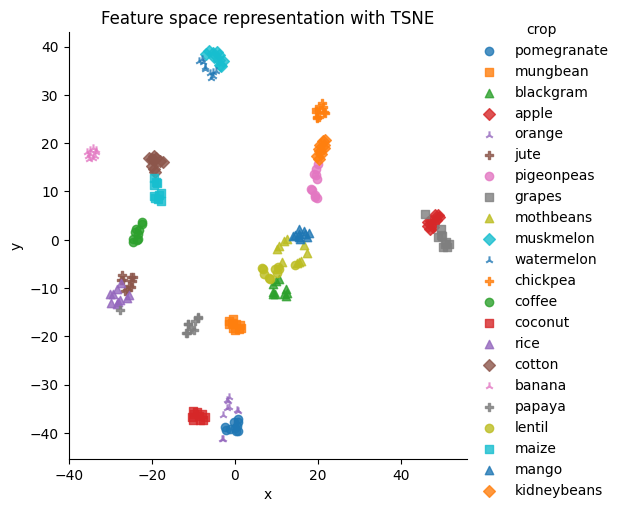


performing TSNE with perplexity 10 and with 1000 iterations at max
[t-SNE] Computing 31 nearest neighbors...
[t-SNE] Indexed 220 samples in 0.000s...
[t-SNE] Computed neighbors for 220 samples in 0.004s...
[t-SNE] Computed conditional probabilities for sample 220 / 220
[t-SNE] Mean sigma: 0.326115
[t-SNE] Computed conditional probabilities in 0.001s
[t-SNE] Iteration 50: error = 55.4035149, gradient norm = 0.2249125 (50 iterations in 0.037s)
[t-SNE] Iteration 100: error = 50.7152634, gradient norm = 0.1723476 (50 iterations in 0.021s)
[t-SNE] Iteration 150: error = 50.0028458, gradient norm = 0.1812387 (50 iterations in 0.019s)
[t-SNE] Iteration 200: error = 49.7672119, gradient norm = 0.1765083 (50 iterations in 0.019s)
[t-SNE] Iteration 250: error = 49.5319633, gradient norm = 0.1647533 (50 iterations in 0.018s)
[t-SNE] KL divergence after 250 iterations with early exaggeration: 49.531963
[t-SNE] Iteration 300: error = 0.3416440, gradient norm = 0.0088260 (50 iterations in 0.018s)
[

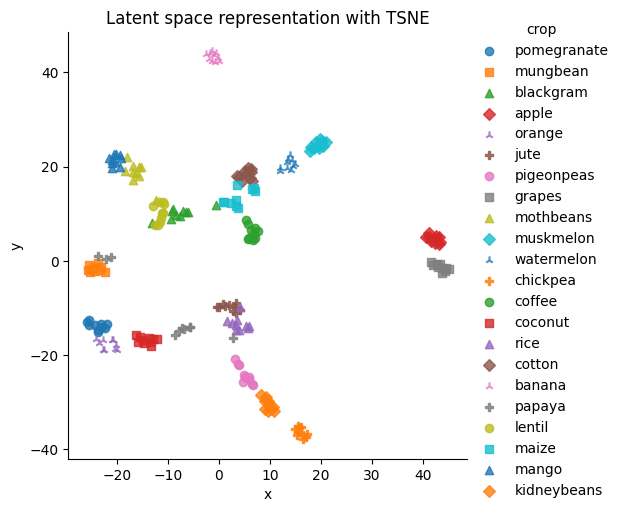


performing PCA
Done...


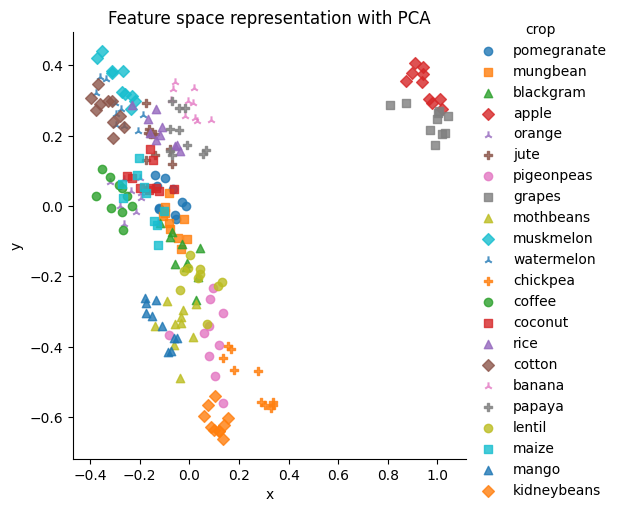


performing PCA
Done...


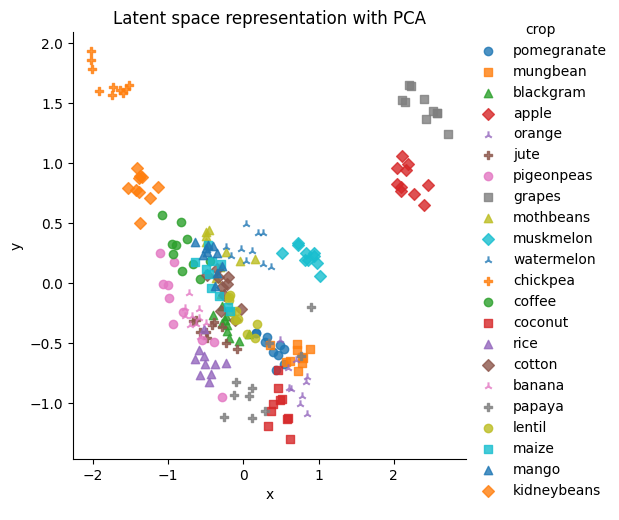


performing UMAP


/Users/timhager/Documents/GitHub/LEAF_and_CROP/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done...


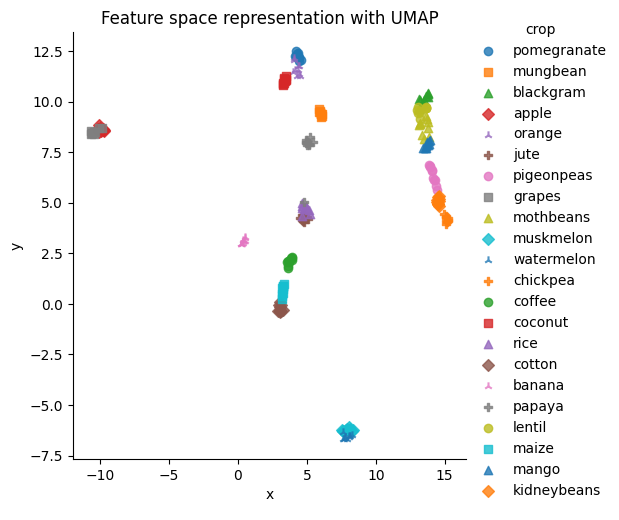


performing UMAP
Done...


/Users/timhager/Documents/GitHub/LEAF_and_CROP/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


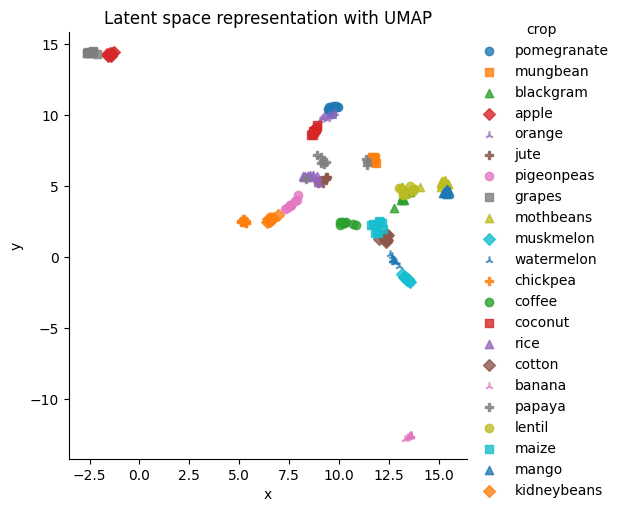

Finished


In [343]:
if __name__ == '__main__':
    if CONFIG.optimization.active:
        optimize()
    else:
        main()